In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

data=pd.DataFrame(housing.data,columns = housing.feature_names)
data["Price"] =housing.target

In [3]:
x = data[['AveRooms']].values
y = data['Price'].values

In [4]:
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize parameters
w = 0
b = 0

learning_rate = 0.01
epochs = 1000

cost_history = []

n = len(x_train_scaled)


for i in range(epochs):

    
    y_pred = w * x_train_scaled.flatten() + b

    
    cost = (1 / (2 * n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)

    
    dw = (1 / n) * np.sum((y_pred - y_train) * x_train_scaled.flatten())
    db = (1 / n) * np.sum(y_pred - y_train)

    
    w = w - learning_rate * dw
    b = b - learning_rate * db

    
    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.6f}")


y_pred_gd = w * x_test_scaled.flatten() + b




Epoch 0, Cost = 2.814871
Epoch 100, Cost = 0.941435
Epoch 200, Cost = 0.690433
Epoch 300, Cost = 0.656804
Epoch 400, Cost = 0.652298
Epoch 500, Cost = 0.651694
Epoch 600, Cost = 0.651613
Epoch 700, Cost = 0.651603
Epoch 800, Cost = 0.651601
Epoch 900, Cost = 0.651601


In [7]:
print("Gradient Descent")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test,y_pred_gd))
print("r2score",r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
r2score 0.013798228607320828


In [8]:
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne) @ x_train_ne.T @ y_train

y_pred_ne = x_test_ne @ theta

In [9]:
print("\nnormal equation")
print("-----------------")
print("intercept:",theta[0])
print("slope:",theta[1])
print("MSE:",mean_squared_error(y_test,y_pred_ne))
print("R2 Score",r2_score(y_test,y_pred_ne))


normal equation
-----------------
intercept: 1.6547622685968417
slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score 0.013795337532284901


In [10]:
sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

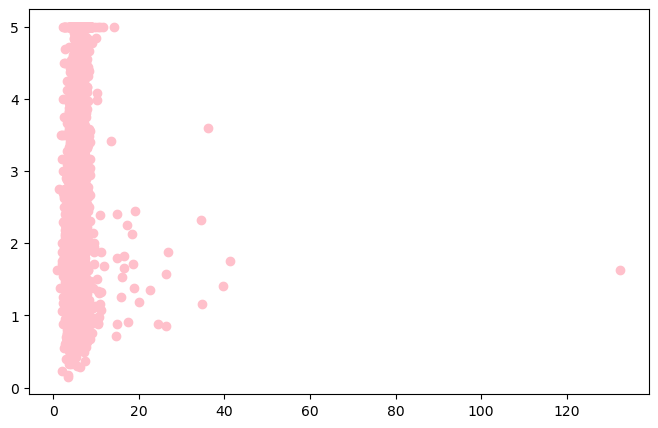

In [11]:
index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x_test,y_test,color='pink',label='Actual Data')

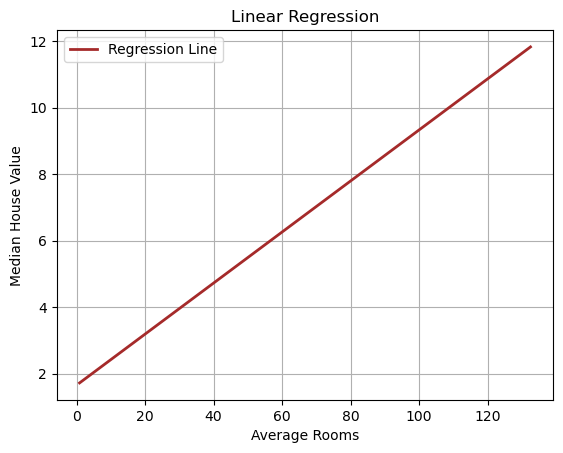

In [12]:
plt.plot(x_test.flatten()[index],y_pred_ne[index],color='brown',linewidth=2,label='Regression Line')
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)
plt.show()

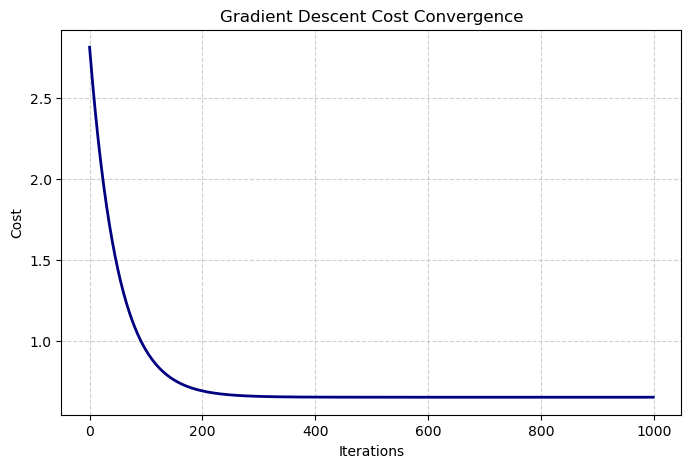

In [13]:
plt.figure(figsize=(8,5))
plt.plot(cost_history, color='navy', linewidth=2)

plt.title("Gradient Descent Cost Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()
